In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
sns.set_theme(style="whitegrid")

# Modelle laden
rf_model  = joblib.load("/Users/saif/Desktop/ML_Load_Forecasting/models/rf_tuned.pkl")
xgb_model = joblib.load("/Users/saif/Desktop/ML_Load_Forecasting/models/xgb_tuned.pkl")

# Gold Layer laden
df = pd.read_csv("/Users/saif/Desktop/ML_Load_Forecasting/data/Gold/df_features_fourier_time_encoding.csv",
                  index_col=0, parse_dates=True)
df.columns = df.columns.str.strip()

X = df.drop(columns=["Load_MW"])
y = df["Load_MW"]

X_train = X[X.index.year < 2023]
X_test  = X[X.index.year == 2023]
y_train = y[y.index.year < 2023]
y_test  = y[y.index.year == 2023]

# Alle Ergebnisse zusammenfassen
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "SVM",
        "Random Forest (tuned)",
        "XGBoost (tuned)",
        "LSTM"
    ],
    "MAE":  [1175, 1131, 560, 520, 371],
    "RMSE": [1467, 1452, 740, 676, 528],
    "R2":   [0.9747, 0.9752, 0.9936, 0.9946, 0.9967]
})

print(results.to_string(index=False))

                Model  MAE  RMSE     R2
    Linear Regression 1175  1467 0.9747
                  SVM 1131  1452 0.9752
Random Forest (tuned)  560   740 0.9936
      XGBoost (tuned)  520   676 0.9946
                 LSTM  371   528 0.9967


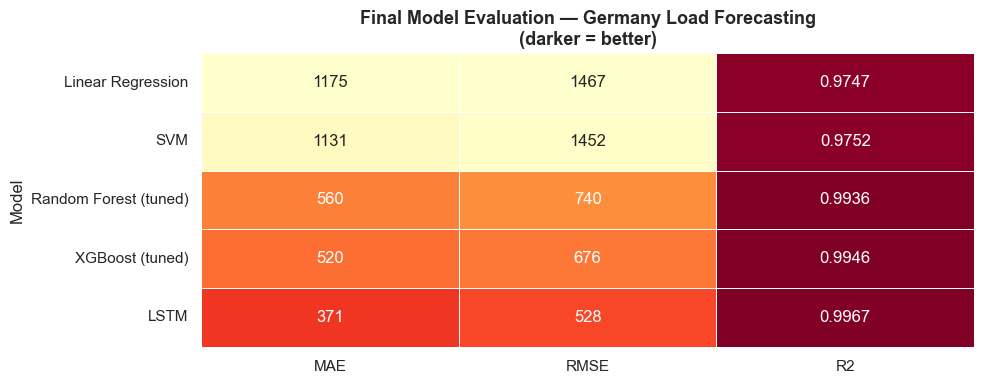

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

# Normalisierte Werte für Heatmap
results_plot = results.set_index("Model")
results_normalized = results_plot.copy()
results_normalized["MAE"]  = 1 - (results_plot["MAE"]  / results_plot["MAE"].max())
results_normalized["RMSE"] = 1 - (results_plot["RMSE"] / results_plot["RMSE"].max())
results_normalized["R2"]   = results_plot["R2"]

sns.heatmap(results_normalized,
            annot=results_plot.round(4),
            fmt="g",
            cmap="YlOrRd",
            ax=ax,
            linewidths=0.5,
            cbar=False)

ax.set_title("Final Model Evaluation — Germany Load Forecasting\n(darker = better)",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/12_final_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/c2/0pncj6ld4glby0b51j0k8dgc0000gn/T/ipykernel_14011/2355855642.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted_mae, x="MAE", y="Model",
/var/folders/c2/0pncj6ld4glby0b51j0k8dgc0000gn/T/ipykernel_14011/2355855642.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted_rmse, x="RMSE", y="Model",
/var/folders/c2/0pncj6ld4glby0b51j0k8dgc0000gn/T/ipykernel_14011/2355855642.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted_r2, x="R2", y="Model",


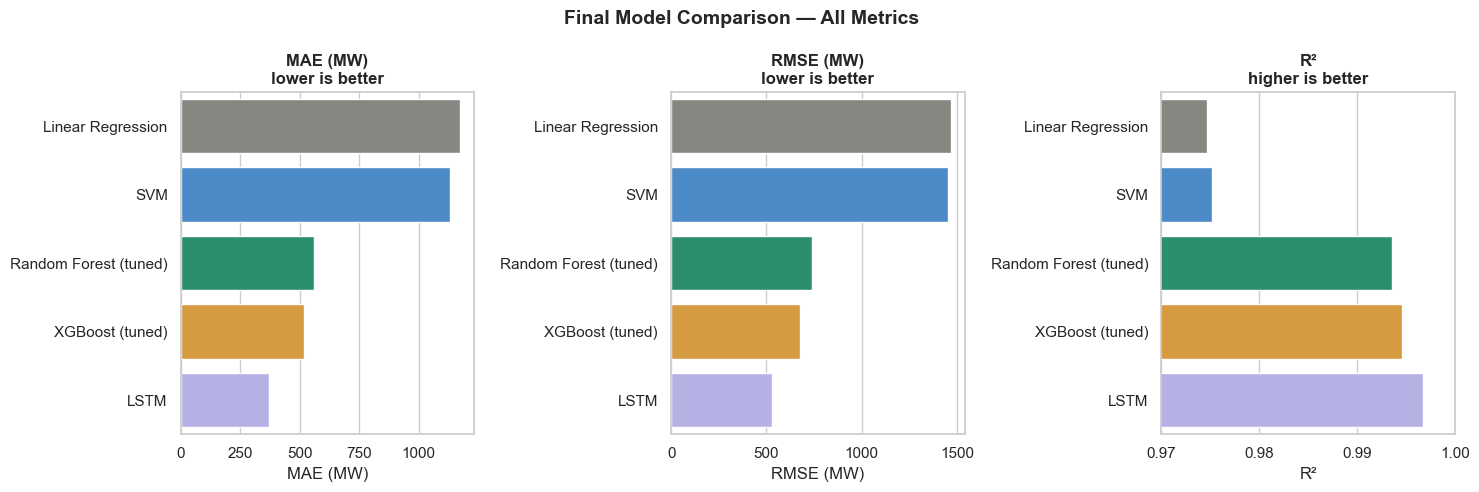

In [7]:
colors = ["#888780", "#378ADD", "#1D9E75", "#EF9F27", "#AFA9EC"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE
df_sorted_mae = results.sort_values("MAE", ascending=False)
sns.barplot(data=df_sorted_mae, x="MAE", y="Model",
            palette=colors, ax=axes[0], orient="h")
axes[0].set_title("MAE (MW)\nlower is better", fontsize=12, fontweight="bold")
axes[0].set_xlabel("MAE (MW)")
axes[0].set_ylabel("")

# RMSE
df_sorted_rmse = results.sort_values("RMSE", ascending=False)
sns.barplot(data=df_sorted_rmse, x="RMSE", y="Model",
            palette=colors, ax=axes[1], orient="h")
axes[1].set_title("RMSE (MW)\nlower is better", fontsize=12, fontweight="bold")
axes[1].set_xlabel("RMSE (MW)")
axes[1].set_ylabel("")

# R²
df_sorted_r2 = results.sort_values("R2", ascending=True)
sns.barplot(data=df_sorted_r2, x="R2", y="Model",
            palette=colors, ax=axes[2], orient="h")
axes[2].set_title("R²\nhigher is better", fontsize=12, fontweight="bold")
axes[2].set_xlabel("R²")
axes[2].set_ylabel("")
axes[2].set_xlim(0.97, 1.0)

plt.suptitle("Final Model Comparison — All Metrics",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/13_final_all_metrics.png", dpi=150, bbox_inches="tight")
plt.show()